In [1]:
import re
from collections import Counter

import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

чтение текста

In [2]:
file_name = "data/The_Fellowship_Of_The_Ring.txt"

with open(file_name, "r", encoding="utf-8", errors="ignore") as f:
    text = f.read()

print("Файл загружен:", file_name)
print("Длина текста:", len(text))

Файл загружен: data/The_Fellowship_Of_The_Ring.txt
Длина текста: 947259


# Задание 2
подготовка данных

In [3]:
# =========================
# 2. Подготовка данных
# =========================
def prepare_sentences(text):
    text = text.lower()
    text = text.replace("’", "'")
    parts = re.split(r"[.!?\n]+", text)

    sentences = []
    for part in parts:
        words = re.findall(r"[a-z]+", part)
        words = [w for w in words if len(w) > 1 or w in {"a", "i"}]
        if len(words) >= 2:
            sentences.append(words)

    return sentences


sentences = prepare_sentences(text)
all_words = [w for sent in sentences for w in sent]
freq = Counter(all_words)

print("Количество предложений:", len(sentences))
print("Всего слов:", len(all_words))
print("Размер словаря:", len(freq))

Количество предложений: 14252
Всего слов: 185654
Размер словаря: 8634


In [4]:
class EpochLogger(CallbackAny2Vec):
    def __init__(self, name):
        self.name = name
        self.epoch = 0
        self.prev_loss = 0.0
        self.losses = []
    def on_epoch_begin(self, model):
        print(f"\n[{self.name}] Эпоха {self.epoch + 1} началась")

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        epoch_loss = loss - self.prev_loss
        self.prev_loss = loss
        self.losses.append(epoch_loss)

        print(f"[{self.name}] Эпоха {self.epoch + 1} завершена")
        print(f"[{self.name}] Loss за эпоху: {epoch_loss:.4f}")

        self.epoch += 1

Обучение Skip-Gram

In [5]:
skip_model = Word2Vec(
    vector_size=100,
    window=4,
    min_count=3,
    workers=1,
    sg=1,
    hs=0,
    negative=10,
    epochs=7,
    seed=42
)

skip_model.build_vocab(sentences)

skip_logger = EpochLogger("Skip-Gram")
skip_model.train(
    sentences,
    total_examples=skip_model.corpus_count,
    epochs=skip_model.epochs,
    compute_loss=True,
    callbacks=[skip_logger]
)

print("\nSkip-Gram обучена")
print("Размер словаря Skip-Gram:", len(skip_model.wv))


[Skip-Gram] Эпоха 1 началась
[Skip-Gram] Эпоха 1 завершена
[Skip-Gram] Loss за эпоху: 1906825.2500

[Skip-Gram] Эпоха 2 началась
[Skip-Gram] Эпоха 2 завершена
[Skip-Gram] Loss за эпоху: 1451623.0000

[Skip-Gram] Эпоха 3 началась
[Skip-Gram] Эпоха 3 завершена
[Skip-Gram] Loss за эпоху: 1318993.2500

[Skip-Gram] Эпоха 4 началась
[Skip-Gram] Эпоха 4 завершена
[Skip-Gram] Loss за эпоху: 1185530.5000

[Skip-Gram] Эпоха 5 началась
[Skip-Gram] Эпоха 5 завершена
[Skip-Gram] Loss за эпоху: 1180512.5000

[Skip-Gram] Эпоха 6 началась
[Skip-Gram] Эпоха 6 завершена
[Skip-Gram] Loss за эпоху: 1178322.0000

[Skip-Gram] Эпоха 7 началась
[Skip-Gram] Эпоха 7 завершена
[Skip-Gram] Loss за эпоху: 1115162.5000

Skip-Gram обучена
Размер словаря Skip-Gram: 3998


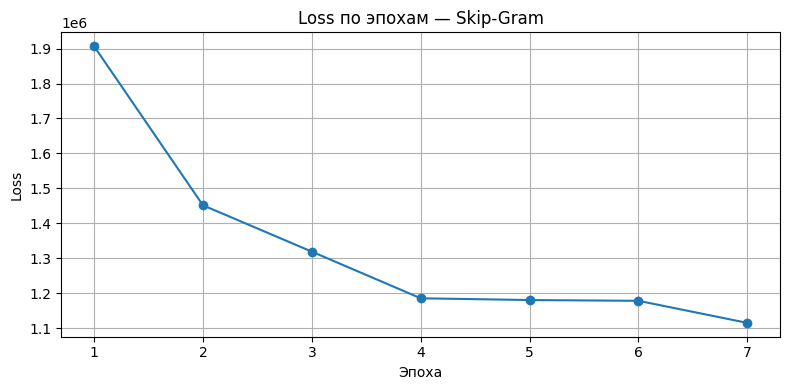

In [6]:
skip_epochs = list(range(1, len(skip_logger.losses) + 1))

plt.figure(figsize=(8, 4))
plt.plot(skip_epochs, skip_logger.losses, marker="o")
plt.title("Loss по эпохам — Skip-Gram")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

top-5 похожих слов

In [7]:
def print_top5_similar(model, word):
    word = word.lower()

    if word not in model.wv:
        print(f"\nСлова '{word}' нет в словаре")
        return

    print(f"\nТоп-5 слов для '{word}':")
    for near_word, score in model.wv.most_similar(word, topn=5):
        print(f"{near_word:15s} {score:.4f}")

test_words = [
    "ring",
    "frodo",
    "gandalf",
    "shire",
    "sam",
    "bilbo",
    "mordor",
    "road",
    "hobbit",
    "black"
]

for word in test_words:
    print_top5_similar(skip_model, word)


Топ-5 слов для 'ring':
desire          0.7710
party           0.7575
word            0.7459
burden          0.7414
sauron          0.7404

Топ-5 слов для 'frodo':
boromir         0.8633
gandalf         0.8585
strider         0.8421
wizard          0.8420
pippin          0.8389

Топ-5 слов для 'gandalf':
strider         0.9209
aragorn         0.9027
elrond          0.8942
wizard          0.8874
boromir         0.8862

Топ-5 слов для 'shire':
parts           0.8507
wild            0.8429
especially      0.8375
nine            0.8354
bree            0.8341

Топ-5 слов для 'sam':
pippin          0.9031
merry           0.8919
maggot          0.8523
wizard          0.8502
aragorn         0.8361

Топ-5 слов для 'bilbo':
baggins         0.8760
gollum          0.8434
agol            0.8298
peregrin        0.8256
butterbur       0.8169

Топ-5 слов для 'mordor':
rohan           0.9357
gondor          0.9245
moria           0.9125
fangorn         0.9090
dwell           0.9044

Топ-5 слов для 'roa

обучение CBOW

In [8]:
cbow_model = Word2Vec(
    vector_size=150,
    window=4,
    min_count=5,
    sample=1e-3,
    workers=1,
    sg=0,
    hs=0,
    negative=10,
    epochs=50,
    seed=42
)

cbow_model.build_vocab(sentences)

cbow_logger = EpochLogger("CBOW")
cbow_model.train(
    sentences,
    total_examples=cbow_model.corpus_count,
    epochs=cbow_model.epochs,
    compute_loss=True,
    callbacks=[cbow_logger]
)

print("\nCBOW обучена")
print("Размер словаря CBOW:", len(cbow_model.wv))


[CBOW] Эпоха 1 началась
[CBOW] Эпоха 1 завершена
[CBOW] Loss за эпоху: 519189.9688

[CBOW] Эпоха 2 началась
[CBOW] Эпоха 2 завершена
[CBOW] Loss за эпоху: 424212.1562

[CBOW] Эпоха 3 началась
[CBOW] Эпоха 3 завершена
[CBOW] Loss за эпоху: 408220.6250

[CBOW] Эпоха 4 началась
[CBOW] Эпоха 4 завершена
[CBOW] Loss за эпоху: 395094.6250

[CBOW] Эпоха 5 началась
[CBOW] Эпоха 5 завершена
[CBOW] Loss за эпоху: 379306.1250

[CBOW] Эпоха 6 началась
[CBOW] Эпоха 6 завершена
[CBOW] Loss за эпоху: 330862.7500

[CBOW] Эпоха 7 началась
[CBOW] Эпоха 7 завершена
[CBOW] Loss за эпоху: 325436.5000

[CBOW] Эпоха 8 началась
[CBOW] Эпоха 8 завершена
[CBOW] Loss за эпоху: 319586.5000

[CBOW] Эпоха 9 началась
[CBOW] Эпоха 9 завершена
[CBOW] Loss за эпоху: 314631.7500

[CBOW] Эпоха 10 началась
[CBOW] Эпоха 10 завершена
[CBOW] Loss за эпоху: 310907.5000

[CBOW] Эпоха 11 началась
[CBOW] Эпоха 11 завершена
[CBOW] Loss за эпоху: 306667.2500

[CBOW] Эпоха 12 началась
[CBOW] Эпоха 12 завершена
[CBOW] Loss за эпоху

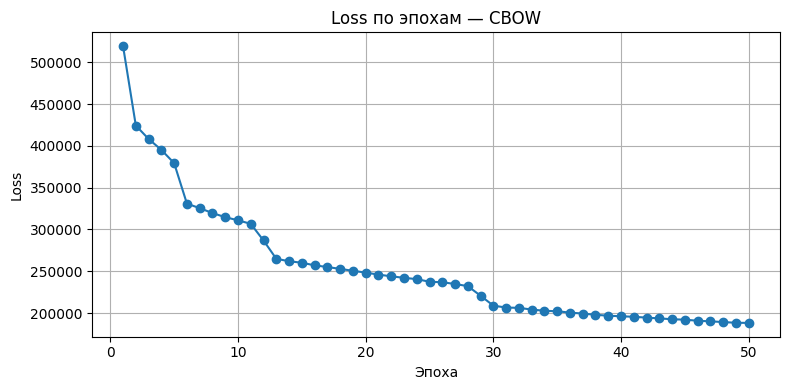

In [9]:
cbow_epochs = list(range(1, len(cbow_logger.losses) + 1))

plt.figure(figsize=(8, 4))
plt.plot(cbow_epochs, cbow_logger.losses, marker="o")
plt.title("Loss по эпохам — CBOW")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

предсказания слова по контексту

In [10]:
def predict_target_by_context(model, context_words, topn=5):
    context_words = [w.lower() for w in context_words]
    context_words = [w for w in context_words if w in model.wv.key_to_index]

    if not context_words:
        print("\nНет слов из контекста в словаре модели")
        return

    print("\nКонтекст:", context_words)

    result = model.predict_output_word(context_words, topn=topn)

    if result is None:
        print("Модель не смогла сделать предсказание")
        return

    print("Предсказание целевого слова:")
    for word, score in result:
        print(f"{word:15s} {score:.4f}")

context_examples = [
    ["great", "war", "ring"],            # ожидаемо что-то про history / tale / ring
    ["after", "hobbit", "written"],      # ожидаемо publication / sequel / begun
    ["mythology", "legends", "elder"],   # ожидаемо days / order / complete
    ["elvish", "history", "tongues"],    # ожидаемо background / linguistic
    ["older", "world", "became"],        # ожидаемо story / drawn
    ["elrond", "gondolin", "elves"],     # ожидаемо high / older / matter
    ["war", "legendary", "conclusion"],  # ожидаемо process / resemble
    ["hobbits", "ancient", "people"],    # ожидаемо unobtrusive / very
    ["peace", "quiet", "earth"],         # ожидаемо tilled / good / love
    ["disappearing", "swiftly", "silently"],  # ожидаемо art / first
    ["yellow", "green", "bright"],       # ожидаемо colours / fond
    ["elves", "dwarves", "relatives"],   # ожидаемо nearer / men / ours
    ["upper", "vales", "anduin"],        # ожидаемо dwelt / time
    ["mountains", "eriador", "crossing"],# ожидаемо perilous / hard
    ["forest", "darkened", "shadow"],    # ожидаемо fell / became
]

for ctx in context_examples:
    predict_target_by_context(cbow_model, ctx)


Контекст: ['great', 'war', 'ring']
Предсказание целевого слова:
iron            0.0221
power           0.0217
rings           0.0174
wield           0.0151
horn            0.0136

Контекст: ['after', 'hobbit', 'written']
Предсказание целевого слова:
brief           0.0152
old             0.0140
dinner          0.0132
children        0.0126
looks           0.0083

Контекст: ['legends', 'elder']
Предсказание целевого слова:
days            0.4676
years           0.0067
halls           0.0044
history         0.0034
legends         0.0032

Контекст: ['elvish', 'history', 'tongues']
Предсказание целевого слова:
ancient         0.0372
history         0.0194
elvish          0.0137
an              0.0109
family          0.0108

Контекст: ['older', 'world', 'became']
Предсказание целевого слова:
half            0.0271
work            0.0173
mountains       0.0098
wider           0.0097
changing        0.0097

Контекст: ['elrond', 'elves']
Предсказание целевого слова:
spoke           0.0506
won

In [11]:
def predict_missing_word_from_sentence(model, sentence, missing_index, window=2, topn=5):
    words = re.findall(r"[a-z']+", sentence.lower())

    if missing_index < 0 or missing_index >= len(words):
        print("\nНеверный индекс пропущенного слова")
        return

    real_target = words[missing_index]

    left = max(0, missing_index - window)
    right = min(len(words), missing_index + window + 1)

    context = []
    for i in range(left, right):
        if i != missing_index and words[i] in model.wv.key_to_index:
            context.append(words[i])

    if not context:
        print("\nКонтекст пустой после фильтрации")
        return

    print("\nИсходное предложение:", " ".join(words))
    print("Настоящее целевое слово:", real_target)
    print("Локальный контекст:", context)

    result = model.predict_output_word(context, topn=topn)

    if result is None:
        print("Модель не смогла сделать предсказание")
        return

    print("Топ предсказаний:")
    for word, score in result:
        print(f"{word:15s} {score:.4f}")

sentence_examples = [
    ("frodo and sam returned to the shire", 6),      # shire
    ("bilbo found the ring in the dark", 3),         # ring
    ("gandalf was a wise wizard", 4),                # wizard
    ("the black riders followed the road", 2),       # riders
    ("the hobbit carried the ring", 4),              # ring
    ("sam stayed with frodo", 3),                    # frodo
    ("the company went through moria", 4),           # moria
    ("the river carried the boat", 2),               # carried
    ("the elves came in the night", 1),              # elves
    ("the road went ever on", 1)                     # road
]

for sent, idx in sentence_examples:
    predict_missing_word_from_sentence(cbow_model, sent, idx)


Исходное предложение: frodo and sam returned to the shire
Настоящее целевое слово: shire
Локальный контекст: ['to', 'the']
Топ предсказаний:
seemed          0.0059
ferry           0.0054
according       0.0051
company         0.0049
ring            0.0044

Исходное предложение: bilbo found the ring in the dark
Настоящее целевое слово: ring
Локальный контекст: ['found', 'the', 'in', 'the']
Топ предсказаний:
shire           0.0127
ring            0.0086
himself         0.0075
world           0.0067
flats           0.0061

Исходное предложение: gandalf was a wise wizard
Настоящее целевое слово: wizard
Локальный контекст: ['a', 'wise']
Топ предсказаний:
such            0.0315
gift            0.0204
even            0.0169
would           0.0118
small           0.0085

Исходное предложение: the black riders followed the road
Настоящее целевое слово: riders
Локальный контекст: ['the', 'black', 'followed', 'the']
Топ предсказаний:
riders          0.1219
by              0.0502
door            

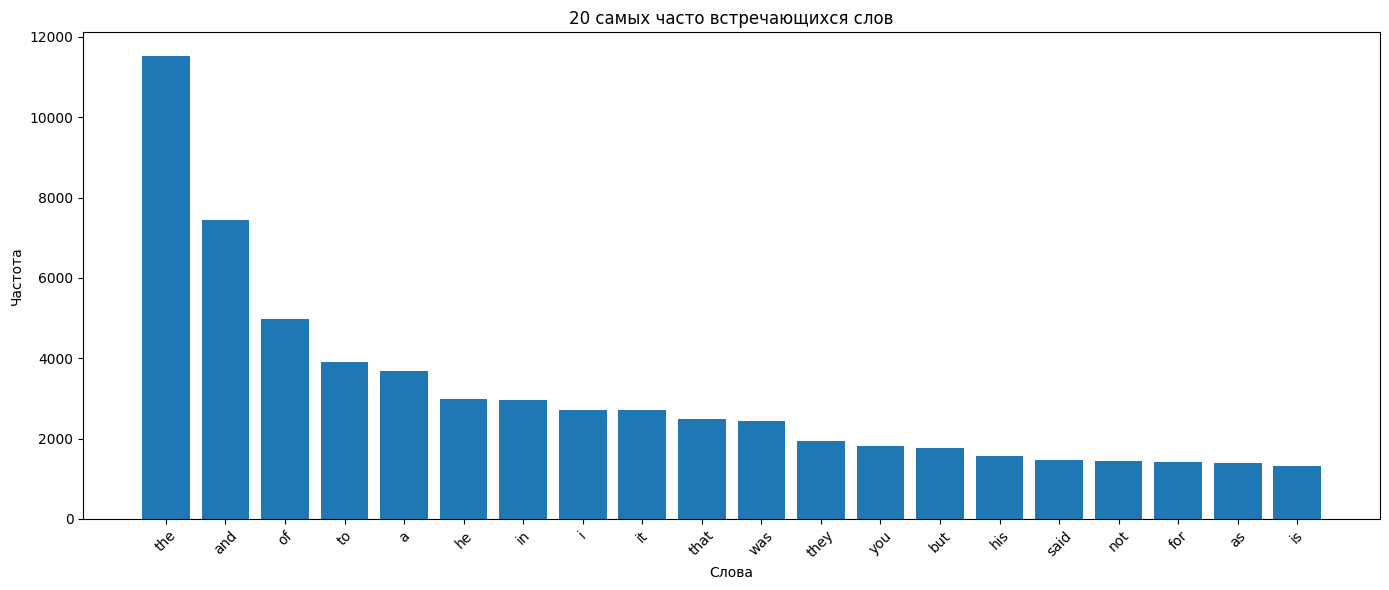

In [12]:
# =========================
# 10. График 20 самых частых слов
# =========================
top_n = 20
top_words = freq.most_common(top_n)

words = [w for w, c in top_words]
counts = [c for w, c in top_words]

plt.figure(figsize=(14, 6))
plt.bar(words, counts)
plt.title("20 самых часто встречающихся слов")
plt.xlabel("Слова")
plt.ylabel("Частота")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()